In [163]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skfuzzy as fuzz

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from umap import UMAP

from transformers import AutoTokenizer, AutoModel, logging as hf_logging
import torch

from metrics_utils import *
from preprocessing_utils import ensure_nltk_resources, preprocess_texts

ensure_nltk_resources()
hf_logging.set_verbosity_error()

seed = 42
np.random.seed(seed)

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/bernardod/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/bernardod/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [164]:
from enum import Enum

class Categories(Enum):
    CS = "Computer Science"
    PHYS = "Physics"
    MATH = "Mathematics"
    EESS = "Electrical Eng & Systems Sci"
    STAT = "Statistics"
    Q_BIO = "Quantitative Biology"
    Q_FIN = "Quantitative Finance"
    ECON = "Economics"

BASE_PATH = "../datasets/new"

DATASETS = {
    Categories.CS: f"{BASE_PATH}/papers_20230218-20260218_trustworthy_AI.csv",
    Categories.PHYS: f"{BASE_PATH}/papers_20230217-20260217_Condensed_Matter_Superconductivity.csv",
    Categories.MATH: f"{BASE_PATH}/papers_20230218-20260218_Fluid_Dynamics.csv",
    Categories.EESS: f"{BASE_PATH}/papers_20230224-20260224_medical_image_processing.csv",
    Categories.STAT: f"{BASE_PATH}/papers_20230224-20260224_statistical_machine_learning.csv",
    Categories.Q_BIO: f"{BASE_PATH}/papers_20220224-20260224_neural_dynamics.csv",
    Categories.Q_FIN: f"{BASE_PATH}/papers_20220224-20260224_Portfolio_optimization.csv",
    Categories.ECON: f"{BASE_PATH}/papers_20230224-20260224_econometric_modeling.csv"
}

In [165]:
CONFIG = {
    # Set the current experiment category
    "category": Categories.CS,

    "title_column": "title",
    "abstract_column": "abstract",

    "vectorizers_to_run": ["tfidf", "sentence-transformers/all-MiniLM-L6-v2", "allenai/scibert_scivocab_uncased"],

    "tfidf": dict(min_df=3, max_df=0.7, max_features=3000, ngram_range=(1, 3)),
    "svd_components": [5, 10, 15, 20, 25, 30, 35, 50, 75],
    "use_svd": True,

    "K_values": [3, 4, 5, 6, 7, 8, 9, 10, 12, 15],
    "algorithms": ["fcm", "kmeans", "agglomerative"],
}

In [166]:
from pathlib import Path


def save_to_excel_sheet(
    results: pd.DataFrame,
    sheet_name: str,
    *,
    file: Path,
    drop_cols: list[str] | None = None,
):
    df = results.copy()
    if drop_cols != None:
        df = df.drop(columns=drop_cols)

    file.parent.mkdir(parents=True, exist_ok=True)

    if file.exists():
        # append mode
        with pd.ExcelWriter(
            file,
            engine="openpyxl",
            mode="a",
            if_sheet_exists="replace"
        ) as writer:
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        # write mode, can't use if_sheet_exists here
        with pd.ExcelWriter(
            file,
            engine="openpyxl",
            mode="w"
        ) as writer:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

In [167]:
category = CONFIG["category"]
df = pd.read_csv(DATASETS[category], dtype=str)

In [168]:
df.head(1)

,arxiv_id,authors,updated,pdf_link,main_category,categories,title,abstract,published,link
0,2504.07170v2,['Jesse C. Cresswell'],2025-11-03 01:42:55+00:00,https://arxiv.org/pdf/2504.07170v2,Machine Learning,"['Machine Learning', 'Artificial Intelligence']",Trustworthy AI Must Account for Interactions,Trustworthy AI encompasses many aspirational a...,2025-04-09 18:00:00+00:00,http://arxiv.org/abs/2504.07170v2


In [169]:
texts = (df[CONFIG["title_column"]] + " " + df[CONFIG["abstract_column"]]).tolist()
texts_clean = preprocess_texts(texts, use_pos=True)

In [170]:
def tfidf_vectorize(texts):
    vectorizer = TfidfVectorizer(
        ngram_range=CONFIG["tfidf"]["ngram_range"],
        min_df=CONFIG["tfidf"]["min_df"],
        max_df=CONFIG["tfidf"]["max_df"],
        max_features=CONFIG["tfidf"]["max_features"],
        stop_words="english",
    )
    return vectorizer.fit_transform(texts)

def sentence_transformers_vectorize(model_name, texts):
    model = SentenceTransformer(model_name)
    X = model.encode(texts, show_progress_bar=True)
    X = normalize(X, norm="l2")
    return X

model_cache = {}
def bert_vectorize(texts, model_name, batch_size=32):
    if not model_name in model_cache:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
        model_cache[model_name] = (tokenizer, model)
    else:
        tokenizer, model = model_cache[model_name]

    model.eval()
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        
        with torch.inference_mode():
            output = model(**encoded, return_dict=True)
        
        attention_mask = encoded["attention_mask"]
        token_embeddings = output.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        embeddings = (token_embeddings * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)
        
        all_embeddings.append(embeddings.cpu().numpy())
    
    X = np.vstack(all_embeddings)
    X = normalize(X, norm="l2")
    return X

In [171]:
def vectorize(vec_name, texts_clean):
    if vec_name == "tfidf":
        return tfidf_vectorize(texts_clean)
    elif "sentence-transformers" in vec_name:
        return sentence_transformers_vectorize(vec_name, texts_clean)
    else:
        return bert_vectorize(texts_clean, vec_name)

In [172]:
def build_X(X_base, n_comp=None, use_svd=False):
    """
    Returns final X that all algorithms will use.
    - If use_svd=False: returns dense array (Assumes it's already normalized).
    - Se use_svd=True: apply SVD with n_comp.
    """

    if not use_svd:
        return X_base.toarray() if hasattr(X_base, "toarray") else np.asarray(X_base)
    
    svd = TruncatedSVD(n_components=n_comp, random_state=seed)
    X = svd.fit_transform(X_base)
    X = normalize(X, norm="l2")
    return X

In [173]:
def cluster_fcm(X, K, m=1.7, error=0.005, maxiter=1000):
    cntr, U, *_rest, fpc = fuzz.cluster.cmeans(
        X.T, c=K, m=m, error=error, maxiter=maxiter, seed=seed,
    )
    U = U.T
    labels = U.argmax(axis=1)
    return labels, {"fpc": float(fpc), "U": U}

def cluster_kmeans(X, K, max_iter=300):
    model = KMeans(
        n_clusters=K, random_state=seed, init="k-means++", max_iter=max_iter
    )
    labels = model.fit_predict(X)
    return labels, {"inertia": float(model.inertia_)}

def cluster_agglomerative_cluster(X, K):
    model = AgglomerativeClustering(
        n_clusters=K, metric="euclidean", linkage="ward"
    )
    labels = model.fit_predict(X)
    return labels


In [174]:
# For cmeans only
def diagnose_collapse(U):
    eps = 1e-12
    K = U.shape[1]
    entropy = -np.sum(U * np.log(U + eps), axis=1)
    entropy_norm = float(np.mean(entropy) / np.log(K))
    avg_max_memb = float(U.max(axis=1).mean())
    return {
        "collapsed": entropy_norm > 0.85,
        "entropy_norm": entropy_norm,
        "avg_max_memb": avg_max_memb,
    }

def evaluate_all(X, y_pred):
    return {
        "CHI": calculate_chi(X, y_pred),
        "DBI": calculate_dbi(X, y_pred),
        "SIL": calculate_silhouette(X, y_pred)
    }

In [175]:
def append_result(X, base_row, alg_name, y_pred, extras):
    extras = extras or {}
    metrics = evaluate_all(X, y_pred)
    row = {**base_row, "alg": alg_name, **metrics, **extras}
    rows.append(row)

In [176]:
rows = []
n_comp_list = CONFIG["svd_components"] if CONFIG["use_svd"] else [None]

for vec_name in CONFIG["vectorizers_to_run"]:
    print(f"Running vectorizer: {vec_name}")

    X_base = vectorize(vec_name, texts_clean)
    n_comp_list = CONFIG["svd_components"] if CONFIG["use_svd"] else [None]

    for n_comp in n_comp_list:
        X = build_X(X_base, n_comp=n_comp, use_svd=CONFIG["use_svd"])

        for K in CONFIG["K_values"]:
            base_row = {
                "vectorizer": vec_name,
                "use_svd": CONFIG["use_svd"],
                "n_comp": n_comp,
                "K": K,
                "collapsed": False,
                "entropy_norm": np.nan,
                "avg_max_memb": np.nan,
                "fpc": np.nan,
                "inertia": np.nan,
            }

            if "fcm" in CONFIG["algorithms"]:
                y_pred, extra = cluster_fcm(X, K)
                collapse = diagnose_collapse(extra["U"])
                append_result(
                    X, base_row,
                    "FCM", y_pred,
                    {**collapse, "fpc": extra["fpc"]}
                )

            if "kmeans" in CONFIG["algorithms"]:
                y_pred, extra = cluster_kmeans(X, K)
                append_result(
                    X, base_row,
                    "KMeans", y_pred,
                    {"inertia": extra["inertia"]}
                )

            if "agglomerative" in CONFIG["algorithms"]:
                y_pred = cluster_agglomerative_cluster(X, K)
                append_result(X, base_row, "AGG", y_pred, None)

results_all = pd.DataFrame(rows).reset_index(drop=True)

Running vectorizer: tfidf
Running vectorizer: sentence-transformers/all-MiniLM-L6-v2


Batches: 100%|██████████| 10/10 [00:00<00:00, 23.65it/s]


Running vectorizer: allenai/scibert_scivocab_uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1094.13it/s, Materializing param=pooler.dense.weight]                               


In [177]:
filtered = results_all[~((results_all["alg"] == "FCM") & (results_all["collapsed"] == True))]

In [178]:
best_config_per_method = (
    filtered
    .sort_values(
        by=["SIL", "CHI", "DBI"], 
        ascending=[False, False, True]
    )
    .groupby(["vectorizer", "alg"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)


print("(CHI↑, DBI↓, SIL↑)")
print()
print("This table shows the best-performing configuration for each")
print("Vectorizer + Clustering Algorithm pair, ranked by")
print("Silhouette, Calinski-Harabasz, and Davies-Bouldin indices.")
print()
best_config_per_method

(CHI↑, DBI↓, SIL↑)

This table shows the best-performing configuration for each
Vectorizer + Clustering Algorithm pair, ranked by
Silhouette, Calinski-Harabasz, and Davies-Bouldin indices.



,vectorizer,use_svd,n_comp,K,collapsed,entropy_norm,avg_max_memb,fpc,inertia,alg,CHI,DBI,SIL
0,tfidf,True,5,5,False,NaN,NaN,NaN,40.946038,KMeans,171.129609,0.861987,0.612843
1,tfidf,True,5,5,False,0.453865,0.767695,0.654729,NaN,FCM,170.726314,0.878740,0.610011
2,tfidf,True,5,5,False,NaN,NaN,NaN,NaN,AGG,142.533193,0.860786,0.553408
3,sentence-transformers/all-MiniLM-L6-v2,True,5,4,False,NaN,NaN,NaN,38.206970,KMeans,130.218903,1.174066,0.487575
4,sentence-transformers/all-MiniLM-L6-v2,True,5,4,False,0.581657,0.704443,0.581854,NaN,FCM,129.828644,1.181308,0.484353
5,sentence-transformers/all-MiniLM-L6-v2,True,5,4,False,NaN,NaN,NaN,NaN,AGG,118.734268,1.259827,0.445727
6,allenai/scibert_scivocab_uncased,True,5,3,False,0.664653,0.697405,0.579307,NaN,FCM,122.185387,1.379197,0.409179
7,allenai/scibert_scivocab_uncased,True,5,5,False,NaN,NaN,NaN,5.500617,KMeans,92.857292,1.398358,0.348974
8,allenai/scibert_scivocab_uncased,True,5,3,False,NaN,NaN,NaN,NaN,AGG,100.536949,1.508940,0.336354


In [179]:
from datetime import date

today = date.today().strftime("%Y-%m-%d")

In [180]:
path_best_results = Path(f"../results/{today}/best_results.xlsx")
path_best_results.parent.mkdir(parents=True, exist_ok=True)

save_to_excel_sheet(best_config_per_method, sheet_name=category.value, file=path_best_results, drop_cols=["collapsed"])

In [181]:
top_per_alg = (
    filtered
    .sort_values(
        by=["SIL", "CHI", "DBI"], 
        ascending=[False, False, True]
    )
    .groupby("alg")
    .first()
    .reset_index()
    .sort_values(by=["SIL", "CHI", "DBI"], ascending=[False, False, True])
    .reset_index(drop=True)
)

top_per_alg

,alg,vectorizer,use_svd,n_comp,K,collapsed,entropy_norm,avg_max_memb,fpc,inertia,CHI,DBI,SIL
0,KMeans,tfidf,True,5,5,False,NaN,NaN,NaN,40.946038,171.129609,0.861987,0.612843
1,FCM,tfidf,True,5,5,False,0.453865,0.767695,0.654729,NaN,170.726314,0.878740,0.610011
2,AGG,tfidf,True,5,5,False,NaN,NaN,NaN,NaN,142.533193,0.860786,0.553408


In [182]:
def run_one_config(row, texts_clean):
    """Rebuild X and predicted labels (y_pred) from a single row of the dataframe"""

    vec_name = row["vectorizer"]
    alg = row["alg"]
    K = int(row["K"])

    X_base = vectorize(vec_name, texts_clean)

    n_comp = None if (row["n_comp"] is None or np.isnan(row["n_comp"])) else int(row["n_comp"])
    X = build_X(X_base, n_comp=n_comp, use_svd=row["use_svd"])

    if alg == "FCM":
        y_pred, extra = cluster_fcm(X, K)
        return X, y_pred

    if alg == "KMeans":
        y_pred, extra = cluster_kmeans(X, K)
        return X, y_pred

    if alg == "AGG":
        y_pred = cluster_agglomerative_cluster(X, K)
        return X, y_pred

def reduce_to_2d(X, K):
    reducer = UMAP(
        n_components=2,
        n_neighbors=X.shape[0] // K,
        random_state=seed,
    )
    return reducer.fit_transform(X)


In [183]:
from math import ceil

def plot_clusters(
    best_per_group,
    texts_clean,
    alpha=0.75,
    point_size=12,
    figsize_per_plot=(5, 4),
):
    n_plots = len(best_per_group)
    n_cols = 3
    n_rows = ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, (_, row) in zip(axes, best_per_group.iterrows()):
        # Rebuild X and labels for this configuration
        X, y_pred = run_one_config(row, texts_clean)
        K = int(row["K"])

        Z = reduce_to_2d(X, K)

        sc = ax.scatter(
            Z[:, 0],
            Z[:, 1],
            c=y_pred,
            s=point_size,
            alpha=alpha,
        )

        n_comp = row.get("n_comp", None)
        if n_comp is None or np.isnan(n_comp):
            n_comp_str = ""
        else:
            n_comp_str = f", n_comp={int(n_comp)}"

        title = (
            f"{row['vectorizer']} | {row['alg']} | K={int(row['K'])}{n_comp_str}\n"
            f"CHI={row['CHI']:.3f} DBI={row['DBI']:.3f} SIL={row['SIL']:.3f}"
        )

        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # Turn off unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    
    cluster_mgs_dir = Path(f"../results/{today}/cluster_images/")
    cluster_mgs_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(cluster_mgs_dir / f"{category.name}.png")
    
    plt.show()


/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Batches: 100%|██████████| 10/10 [00:00<00:00, 36.35it/s]
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Batches: 100%|██████████| 10/10 [00:00<00:00, 40.15it/s]
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.p

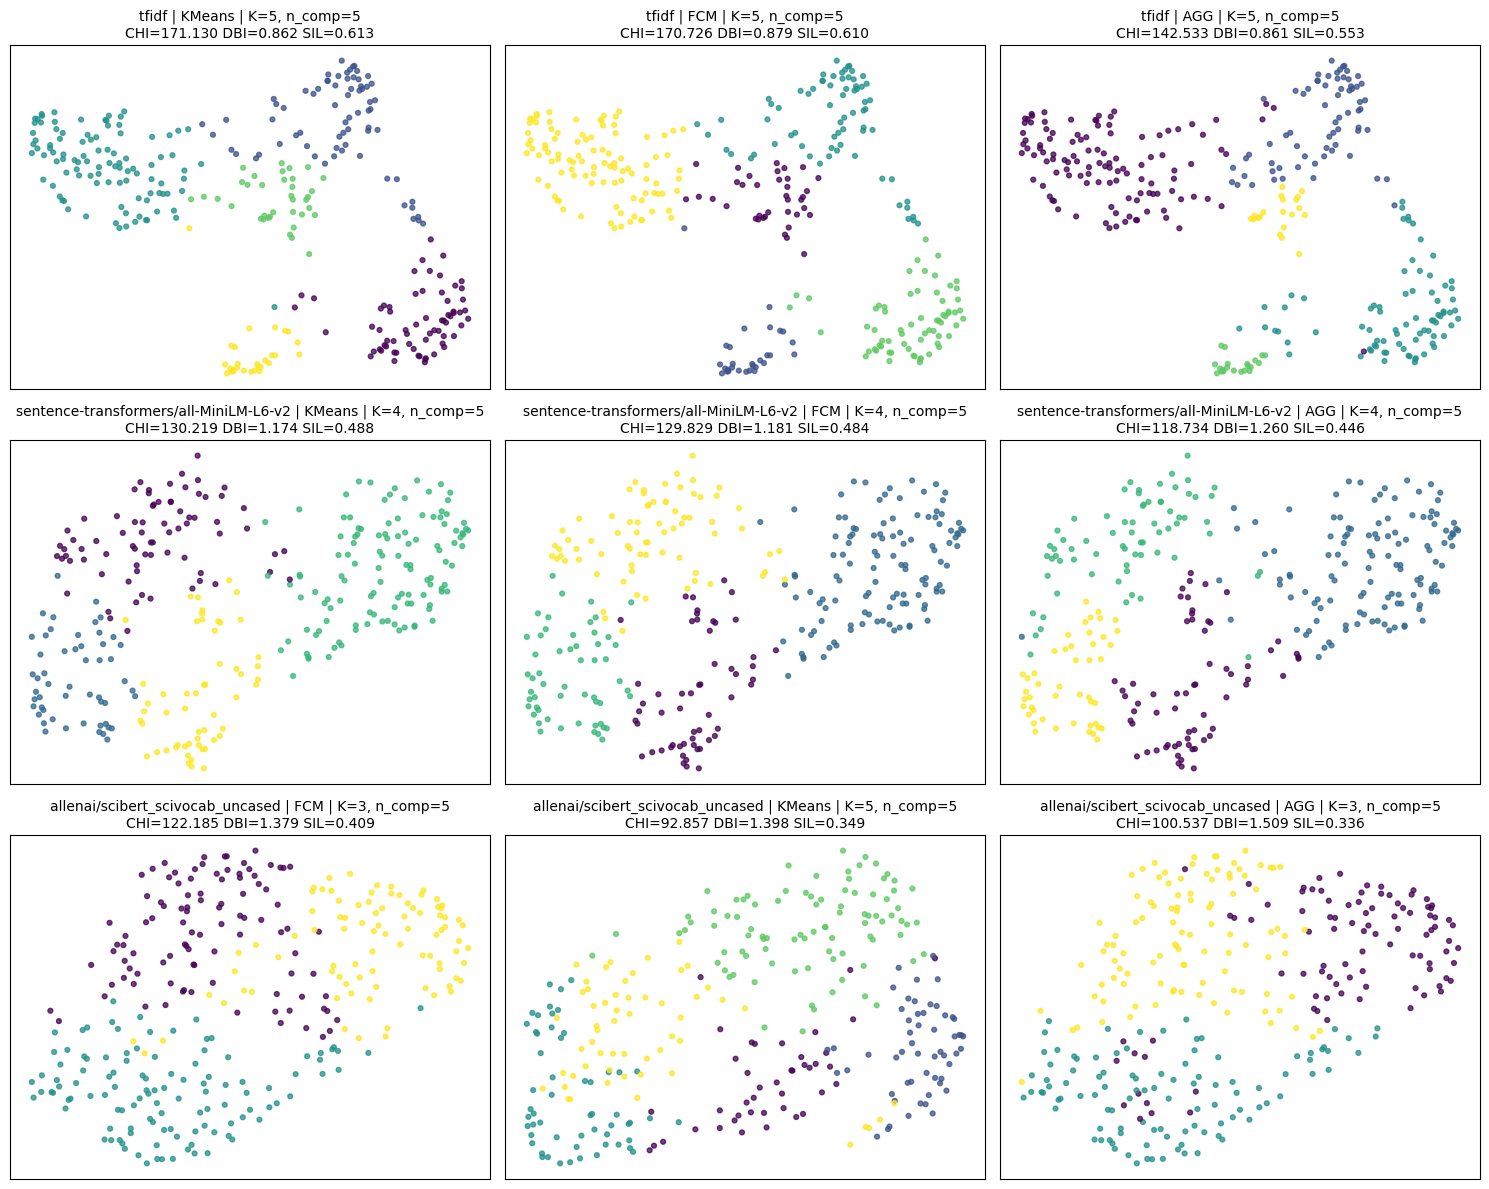

In [184]:
cluster_mgs_dir = Path(f"../results/{today}/cluster_images/")
cluster_mgs_dir.parent.mkdir(parents=True, exist_ok=True)

plot_clusters(best_config_per_method, texts_clean)

#### Save samples of the BEST results for manual analysis.

In [185]:
SAMPLES_FILE = Path(f"../results/{today}/samples_{category.name}.xlsx")

best_row = best_config_per_method.iloc[0].copy()
_, y_pred = run_one_config(best_row, texts_clean)

df_analysis = pd.DataFrame({
    "text": texts_clean,
    "cluster": y_pred
})

best_config_df = pd.DataFrame([best_row.to_dict()])

save_to_excel_sheet(
    best_config_df,
    sheet_name="best_config",
    file=SAMPLES_FILE,
)

N_SAMPLES = 7

for cid in sorted(df_analysis["cluster"].unique()):
    df_c = df_analysis[df_analysis["cluster"] == cid]

    df_samples = (
        df_c[["text"]]
        .sample(n=N_SAMPLES, random_state=seed)
        .reset_index(drop=True)
    )

    save_to_excel_sheet(
        df_samples,
        sheet_name=f"cluster_{cid}",
        file=SAMPLES_FILE,
    )